In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split

In [9]:
def make_spirals(n_samples=2000, noise=0.2):
    n = np.sqrt(np.random.rand(n_samples,1)) * 780 * (2*np.pi)/360
    d1x = -np.cos(n)*n + np.random.rand(n_samples,1)*noise
    d1y =  np.sin(n)*n + np.random.rand(n_samples,1)*noise
    X = np.vstack((np.hstack((d1x,d1y)), 
                   np.hstack((-d1x,-d1y))))
    y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))
    return X.astype(np.float32), y.astype(np.int64)

X, y = make_spirals()

# seperate train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [10]:
# ---------------------------
# 2) Fuzzy C-Means for Initialization
# ---------------------------

def fcm_initialize(X, K, m=2.0):
    """
    X: numpy array shape (N, n_inputs)
    K: number of clusters / rules
    Returns:
        centers: (K, n_inputs)
        spreads: (K, n_inputs)
    """
    X_t = X.T  # (n_inputs, N)
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_t,
        c=K,
        m=m,
        error=1e-5,
        maxiter=2000,
        init=None,
    )
    N = X.shape[0]

    spreads = []
    for k in range(K):
        weights = u[k].reshape(N, 1)   # (N,1)
        diff = X - cntr[k]             # (N, n_inputs)
        denom = np.sum(weights) + 1e-12
        var = np.sum(weights * (diff ** 2), axis=0) / denom
        spreads.append(np.sqrt(var))
    spreads = np.array(spreads)
    spreads = np.clip(spreads, 1e-3, None)
    return np.array(cntr), spreads


In [11]:
# ---------------------------
# 5) Gaussian MF Layer
# ---------------------------
class GaussianMF_FCM(nn.Module):
    def __init__(self, centers_init, spreads_init):
        super().__init__()
        # centers_init: (K, n_inputs), spreads_init: (K, n_inputs)
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]

        # store as parameters so optimizer can tune them
        self.centers = nn.Parameter(torch.tensor(centers_init, dtype=torch.float32))
        # store spreads as positive parameters: store log_sigma to keep positivity
        # but to minimize changes, we'll store spreads directly and enforce positivity via softplus in forward
        self.spreads = nn.Parameter(torch.tensor(spreads_init, dtype=torch.float32))

    def forward(self, x):
        # x: (batch, n_inputs)
        # expand
        x_exp = x.unsqueeze(1)                       # (batch, 1, n_inputs)
        c_exp = self.centers.unsqueeze(0)            # (1, K, n_inputs)
        s_exp = torch.nn.functional.softplus(self.spreads).unsqueeze(0)  # (1, K, n_inputs) positive

        # Gaussian MF: exp(- (x-c)^2 / (2*s^2) )
        # prevent division by zero
        s_exp = torch.clamp(s_exp, min=1e-6)

        mu = torch.exp(-((x_exp - c_exp) ** 2) / (2.0 * (s_exp ** 2)))  # (batch, K, n_inputs)

        # Combine (AND) across inputs by product
        firing = torch.prod(mu, dim=2)  # (batch, K)

        return firing


In [12]:
# ---------------------------
# 6) ANFIS Model With FCM Initialization
# ---------------------------
class ANFIS_FCM(nn.Module):
    def __init__(self, centers_init, spreads_init):
        super().__init__()
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]

        self.mf_layer = GaussianMF_FCM(centers_init, spreads_init)

        # One linear function per rule: coefficients for inputs and a bias
        # shape: (K, n_inputs + 1)
        self.consequents = nn.Parameter(torch.randn(self.K, self.n_inputs + 1, dtype=torch.float32) * 0.1)

    def forward(self, x):
        # x: (batch, n_inputs)
        w = self.mf_layer(x)  # (batch, K)
        w_sum = torch.sum(w, dim=1, keepdim=True) + 1e-8
        w_norm = w / w_sum    # (batch, K)

        # compute rule outputs: y_r for each rule and batch
        # x_exp: (batch, K, n_inputs)
        x_exp = x.unsqueeze(1).expand(-1, self.K, -1)
        # consequents[:, :-1]: (K, n_inputs)
        # will broadcast to (batch, K, n_inputs)
        # Multiply and sum over inputs:
        # First expand consequents to (1, K, n_inputs)
        cons_w = self.consequents[:, :-1].unsqueeze(0)  # (1, K, n_inputs)
        linear_part = torch.sum(x_exp * cons_w, dim=2)   # (batch, K)
        bias = self.consequents[:, -1].unsqueeze(0)     # (1, K)
        y_r = linear_part + bias                        # (batch, K)

        # defuzzify / aggregate
        y_pred = torch.sum(w_norm * y_r, dim=1, keepdim=True)  # (batch, 1)
        return y_pred

In [13]:
# ---------------------------
# 5) Training (RMSE + BCE)
# ---------------------------

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert labels
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32).to(device)

# Initialization
K = 6
centers_init, spreads_init = fcm_initialize(X_train, K)

# Model
model = ANFIS_FCM(centers_init, spreads_init).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCEWithLogitsLoss()   # logits version

n_epochs = 1000
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Forward logits
    y_pred_train_logits = model(X_train_tensor)

    # BCE loss (logits)
    loss = loss_fn(y_pred_train_logits, y_train_tensor)

    # Backprop
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    # Track best model
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Logging every 50 epochs
    if epoch % 100 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            # Convert logits → probability
            train_prob = torch.sigmoid(model(X_train_tensor))
            test_prob  = torch.sigmoid(model(X_test_tensor))

            # RMSE
            train_rmse = torch.sqrt(torch.mean((train_prob - y_train_tensor)**2)).item()
            test_rmse  = torch.sqrt(torch.mean((test_prob  - y_test_tensor )**2)).item()

        print(f"Epoch {epoch}/{n_epochs}  Loss={loss.item():.4f}  "
              f"Train RMSE={train_rmse:.4f}  Test RMSE={test_rmse:.4f}")

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()


# ---------------------------
# 6) Final Evaluation (RMSE)
# ---------------------------
with torch.no_grad():
    final_train_prob = torch.sigmoid(model(X_train_tensor)).cpu().numpy().reshape(-1)
    final_test_prob  = torch.sigmoid(model(X_test_tensor)).cpu().numpy().reshape(-1)

train_rmse = np.sqrt(np.mean((final_train_prob - y_train)**2))
test_rmse  = np.sqrt(np.mean((final_test_prob  - y_test )**2))

print("\nFinal Results:")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")

Epoch 1/1000  Loss=0.8238  Train RMSE=0.5488  Test RMSE=0.5523
Epoch 100/1000  Loss=0.6692  Train RMSE=0.4885  Test RMSE=0.4948
Epoch 200/1000  Loss=0.6433  Train RMSE=0.4766  Test RMSE=0.4801
Epoch 300/1000  Loss=0.6366  Train RMSE=0.4738  Test RMSE=0.4756
Epoch 400/1000  Loss=0.6324  Train RMSE=0.4720  Test RMSE=0.4731
Epoch 500/1000  Loss=0.6287  Train RMSE=0.4705  Test RMSE=0.4712
Epoch 600/1000  Loss=0.6252  Train RMSE=0.4691  Test RMSE=0.4695
Epoch 700/1000  Loss=0.6220  Train RMSE=0.4678  Test RMSE=0.4679
Epoch 800/1000  Loss=0.6188  Train RMSE=0.4666  Test RMSE=0.4665
Epoch 900/1000  Loss=0.6157  Train RMSE=0.4654  Test RMSE=0.4651
Epoch 1000/1000  Loss=0.6127  Train RMSE=0.4643  Test RMSE=0.4638

Final Results:
Train RMSE: 0.4643
Test RMSE : 0.4638


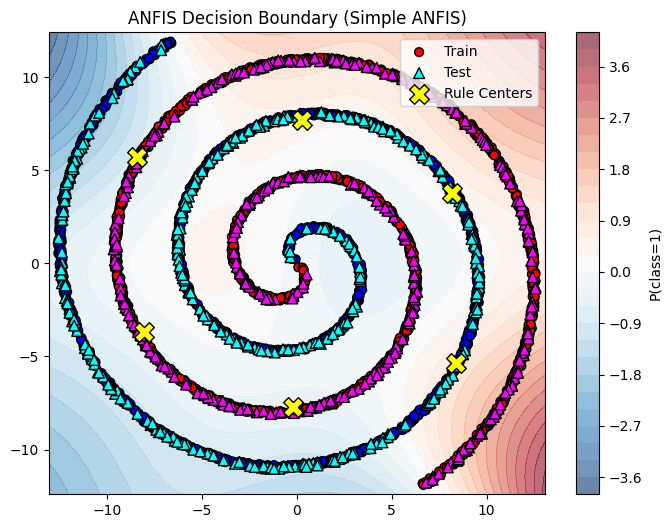

In [14]:
# ---------------------------
# 7: Plot decision boundary (Simple ANFIS)
# ---------------------------
plt.figure(figsize=(8, 6))

# Grid for visualization
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_tensor = torch.from_numpy(grid).to(device)

with torch.no_grad():
    prob_grid = model(grid_tensor).cpu().numpy().reshape(xx.shape)

# Decision boundary contour
contour = plt.contourf(xx, yy, prob_grid, levels=30, cmap="RdBu_r", alpha=0.6)
plt.colorbar(contour, label="P(class=1)")

# Training data
plt.scatter(
    X_train[:, 0], X_train[:, 1], 
    c=y_train, cmap="bwr", edgecolor="k", s=40, label="Train"
)

# Test data
plt.scatter(
    X_test[:, 0], X_test[:, 1], 
    c=y_test, cmap="cool", edgecolor="k", s=60, marker="^", label="Test"
)

# Optional: show rule centers
plt.scatter(
    centers_init[:, 0], centers_init[:, 1],
    c="yellow", s=200, edgecolor="black", marker="X",
    label="Rule Centers"
)

plt.title("ANFIS Decision Boundary (Simple ANFIS)")
plt.legend()
plt.show()
